In [ ]:
!pip install fasttext openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp311-cp311-linux_x86_64.whl size=4313489 sha256=2b74a3e46c80ebf7aa71fbd1c9df40fce019918af0498c34028bc126b1d093c7
  Stored in directory: /root/.cache/pip/wheels/65/4f/35/5057db0249224e9ab55a513fa6b79451473ceb7713017823c3
Successfully built fasttext


In [ ]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.te.300.bin.gz
!gunzip cc.te.300.bin.gz


--2025-04-19 09:09:23--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.te.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.118, 3.171.22.68, 3.171.22.13, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4374284656 (4.1G) [application/octet-stream]
Saving to: ‘cc.te.300.bin.gz’

cc.te.300.bin.gz    100%[===================>]   4.07G  41.4MB/s    in 95s     

2025-04-19 09:10:59 (43.7 MB/s) - ‘cc.te.300.bin.gz’ saved [4374284656/4374284656]



In [ ]:
import pandas as pd
import fasttext
import numpy as np

# Load your Excel
df = pd.read_excel('/content/telugu_indicbert_features.xlsx')

# Load Telugu FastText model
ft_model = fasttext.load_model('/content/cc.te.300.bin')



ValueError: predict processes one line at a time (remove '\n')

In [ ]:
print(df.shape)

(4399, 770)


In [ ]:
# Convert review text to FastText vector after removing newlines
def get_ft_vector(text):
    clean_text = str(text).replace('\n', ' ').strip()
    return ft_model.get_sentence_vector(clean_text)

# Apply to all rows
features = df['comment'].apply(get_ft_vector)  # or 'text_' depending on your column
feature_matrix = np.vstack(features.values)

# Create feature DataFrame
feature_df = pd.DataFrame(feature_matrix, columns=[f'ft_{i}' for i in range(feature_matrix.shape[1])])

# Combine with original data
final_df = pd.concat([df[['comment', 'label']], feature_df], axis=1)

# Save to Excel
final_df.to_excel('telugu_fasttext_features_output.xlsx', index=False)


In [1]:
import pandas as pd

data = pd.read_excel("/content/telugu_fasttext_features_output.xlsx")

In [6]:
import pandas as pd

# Columns you want to exclude
columns_to_exclude = ["comment", "label"]

# Drop those columns
X = data.drop(columns=columns_to_exclude)
y = data['label']
# Now df_filtered is the dataset without the excluded columns
print(x.head())


       ft_0      ft_1      ft_2      ft_3      ft_4      ft_5      ft_6  \
0 -0.001597  0.008228  0.006633 -0.003998 -0.027531 -0.021745 -0.012460   
1  0.022008 -0.010636  0.001651  0.047190 -0.110136 -0.004019  0.007904   
2  0.021655 -0.056541  0.000934 -0.012128 -0.149045  0.018682  0.009678   
3  0.015828  0.008204 -0.008052  0.048584 -0.125499  0.001893  0.014131   
4  0.011997  0.016216  0.010553  0.025839 -0.122688 -0.001579  0.005774   

       ft_7      ft_8      ft_9  ...    ft_290    ft_291    ft_292    ft_293  \
0  0.024087  0.003254 -0.017041  ...  0.020479  0.014334 -0.023167 -0.010975   
1 -0.019126 -0.016369 -0.011110  ... -0.016721 -0.011672 -0.054096 -0.022482   
2  0.005334 -0.013467  0.011281  ...  0.013130  0.013485 -0.045058 -0.002131   
3  0.002100 -0.025245 -0.002796  ...  0.001826  0.008071 -0.044848 -0.024324   
4 -0.004051 -0.008568 -0.017777  ... -0.032633  0.006380 -0.001304 -0.019919   

     ft_294    ft_295    ft_296    ft_297    ft_298    ft_299  
0 -0

KNN

Best Parameters: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.9190086318375792

 Train Accuracy: 0.9977
 Test Accuracy : 0.9420

 Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2346
           1       1.00      0.99      1.00      1173

    accuracy                           1.00      3519
   macro avg       1.00      1.00      1.00      3519
weighted avg       1.00      1.00      1.00      3519


 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       587
           1       0.92      0.90      0.91       293

    accuracy                           0.94       880
   macro avg       0.94      0.93      0.93       880
weighted avg       0.94      0.94      0.94       880



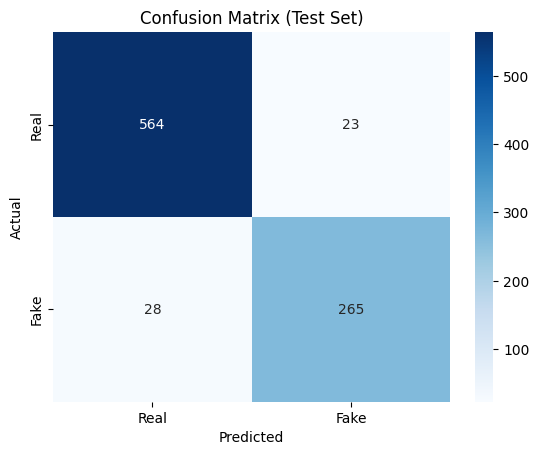

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Define KNN model and hyperparameter grid
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1: Manhattan, p=2: Euclidean
}

# Grid search with 5-fold cross-validation
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#  Best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

#  Evaluate on train and test sets
best_knn = grid.best_estimator_

# Train evaluation
y_train_pred = best_knn.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Test evaluation
y_test_pred = best_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n Train Accuracy: {train_acc:.4f}")
print(f" Test Accuracy : {test_acc:.4f}")

print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# 8. Confusion Matrix (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()


RF

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9258320843454442

 Train Accuracy: 0.9977
 Test Accuracy : 0.9534

 Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2346
           1       1.00      0.99      1.00      1173

    accuracy                           1.00      3519
   macro avg       1.00      1.00      1.00      3519
weighted avg       1.00      1.00      1.00      3519


 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       587
           1       0.99      0.87      0.93       293

    accuracy                           0.95       880
   macro avg       0.96      0.93      0.95       880
weighted avg       0.96      0.95      0.95       880



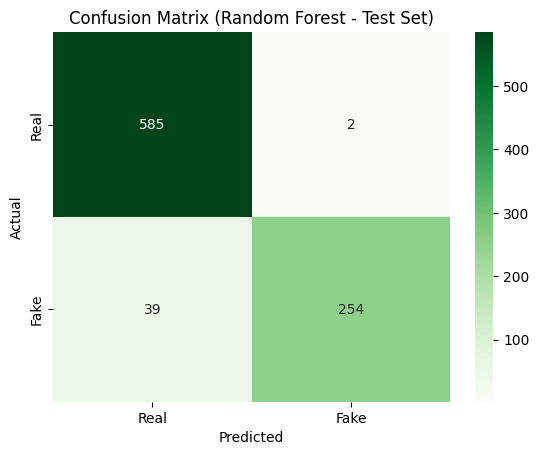

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Define Random Forest model and hyperparameter grid
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

#  Grid search with 5-fold CV
grid = GridSearchCV(rf, param_grid, cv=2, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#  Best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

#  Train and Test Evaluation
best_rf = grid.best_estimator_

# Train
y_train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Test
y_test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n Train Accuracy: {train_acc:.4f}")
print(f" Test Accuracy : {test_acc:.4f}")

print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# 8. Confusion Matrix (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest - Test Set)')
plt.show()


Naive Bayes


 Train Accuracy: 0.7687
 Test Accuracy : 0.7648

 Classification Report (Train):
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      2346
           1       0.69      0.56      0.62      1173

    accuracy                           0.77      3519
   macro avg       0.74      0.72      0.73      3519
weighted avg       0.76      0.77      0.76      3519


 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       587
           1       0.67      0.58      0.62       293

    accuracy                           0.76       880
   macro avg       0.74      0.72      0.72       880
weighted avg       0.76      0.76      0.76       880



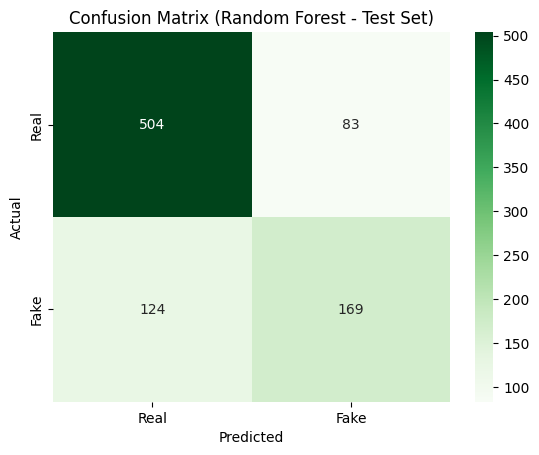

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#  Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

#  Predictions
y_train_pred = nb.predict(X_train)
y_test_pred = nb.predict(X_test)

#  Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n Train Accuracy: {train_acc:.4f}")
print(f" Test Accuracy : {test_acc:.4f}")

#  Classification Reports
print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest - Test Set)')
plt.show()


AdaBoost Classifier

Best Parameters: {'learning_rate': 1.5, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9289550465537308

 Train Accuracy: 0.9824
 Test Accuracy : 0.9477

 Classification Report (Train):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2346
           1       0.99      0.96      0.97      1173

    accuracy                           0.98      3519
   macro avg       0.98      0.98      0.98      3519
weighted avg       0.98      0.98      0.98      3519


 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       587
           1       0.93      0.91      0.92       293

    accuracy                           0.95       880
   macro avg       0.94      0.94      0.94       880
weighted avg       0.95      0.95      0.95       880



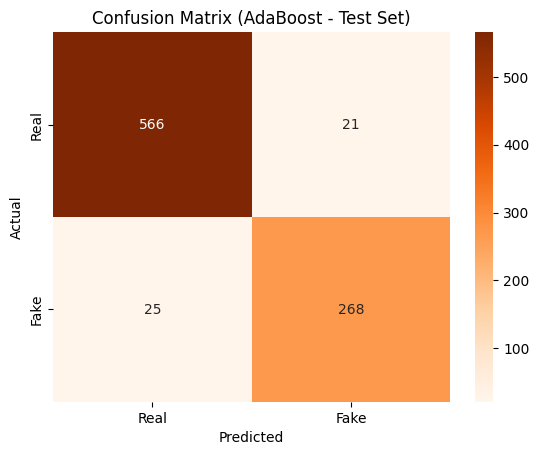

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define AdaBoost model and hyperparameter grid
ada = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5]
}

#  Grid search with 5-fold CV
grid = GridSearchCV(ada, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#  Best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

#  Train and Test Evaluation
best_ada = grid.best_estimator_

y_train_pred = best_ada.predict(X_train)
y_test_pred = best_ada.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n Train Accuracy: {train_acc:.4f}")
print(f" Test Accuracy : {test_acc:.4f}")

print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# 8. Confusion Matrix (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (AdaBoost - Test Set)')
plt.show()


DT

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.8601875532821824

 Train Accuracy: 0.9912
 Test Accuracy : 0.8977

 Classification Report (Train):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2346
           1       1.00      0.97      0.99      1173

    accuracy                           0.99      3519
   macro avg       0.99      0.99      0.99      3519
weighted avg       0.99      0.99      0.99      3519


 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       587
           1       0.88      0.80      0.84       293

    accuracy                           0.90       880
   macro avg       0.89      0.87      0.88       880
weighted avg       0.90      0.90      0.90       880



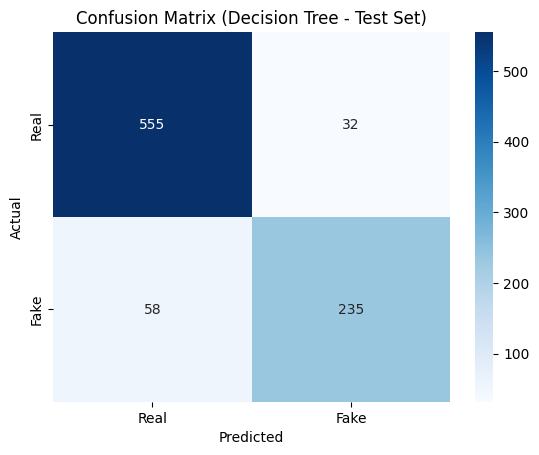

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Define Decision Tree and hyperparameter grid
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Grid Search (no CV because you requested it earlier)
grid = GridSearchCV(dt, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Best params
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

# Evaluate on train and test
best_dt = grid.best_estimator_

y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n Train Accuracy: {train_acc:.4f}")
print(f" Test Accuracy : {test_acc:.4f}")

# 8. Classification Reports
print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Decision Tree - Test Set)')
plt.show()


XGBoost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:31:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 XGBoost Results
 Train Accuracy: 0.9977
 Test Accuracy : 0.9580

 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       587
           1       0.97      0.90      0.93       293

    accuracy                           0.96       880
   macro avg       0.96      0.94      0.95       880
weighted avg       0.96      0.96      0.96       880


 Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2346
           1       1.00      0.99      1.00      1173

    accuracy                           1.00      3519
   macro avg       1.00      1.00      1.00      3519
weighted avg       1.00      1.00      1.00      3519



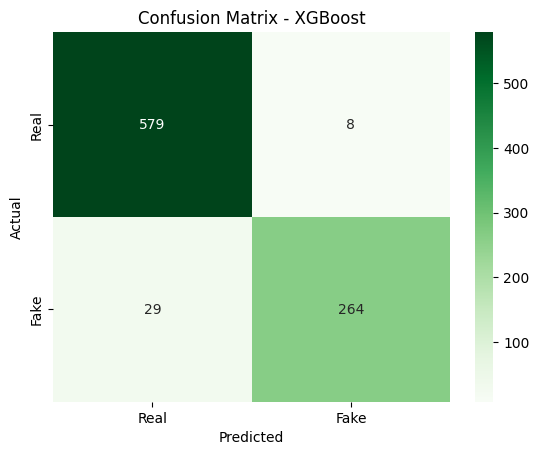

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)

# Predictions
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

# Evaluation
print("\n XGBoost Results")
print(f" Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f" Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))
print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


SVM


 SVM Results
 Train Accuracy: 0.9670
 Test Accuracy : 0.9614

 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       587
           1       0.99      0.90      0.94       293

    accuracy                           0.96       880
   macro avg       0.97      0.95      0.96       880
weighted avg       0.96      0.96      0.96       880


 Classification Report (Train):
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      2346
           1       1.00      0.90      0.95      1173

    accuracy                           0.97      3519
   macro avg       0.98      0.95      0.96      3519
weighted avg       0.97      0.97      0.97      3519



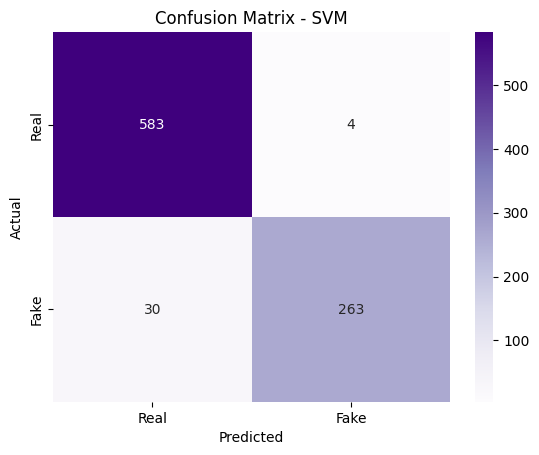

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Train SVM
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train, y_train)

# Predictions
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# Evaluation
print("\n SVM Results")
print(f" Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f" Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


LR

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel('/content/telugu_indicbert_balanced.xlsx')
X = df.iloc[:, :-2]
y = df['label']

# Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# Evaluation
print("\n Logistic Regression Results")
print(f" Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f" Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

print("\n Classification Report (Train):")
print(classification_report(y_train, y_train_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '/content/telugu_indicbert_balanced.xlsx'

MLP

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Train MLP Classifier
mlp_clf = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                        max_iter=300, random_state=42)
mlp_clf.fit(X_train, y_train)

# Predictions
y_train_pred = mlp_clf.predict(X_train)
y_test_pred = mlp_clf.predict(X_test)

# Evaluation
print("\n MLP Classifier Results")
print(f" Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f" Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title("Confusion Matrix - MLP Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
